<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Apple%20Prices%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Apple Prices Dataset


## Unpacking the Apple Price Dataset: Key Insights
This dataset provides a fascinating glimpse into the global apple market, detailing prices, quantities sold, varieties, quality grades, market types, and geographic locations across 500 transaction records. By analyzing these factors, we can uncover the underlying dynamics that drive apple pricing and sales.

What the Data Tells Us at a Glance:

Initially, we observed that the dataset contains a good mix of numerical information, such as Price_per_KG_USD, Quantity_Sold_KG, and Revenue_USD, alongside categorical details like Country, Apple_Variety, Quality_Grade, and Market_Type. The distributions of apple varieties, quality grades, and market types were fairly balanced, indicating a diverse set of transactions rather than a dominance by a single category.

Surprising Economic Realities:

One of the most striking findings from our statistical analysis revolved around price elasticity. Counter-intuitively, our econometric model suggests that changes in the price of apples do not statistically alter the demand volume. This could imply that consumer demand for apples within this dataset is relatively inelastic, meaning people will buy roughly the same amount regardless of minor price fluctuations, or that other unmeasured factors are more influential.

However, quality grade proved to be a significant pricing driver. The analysis revealed a clear statistical difference in prices across quality grades (Economy, Standard, Premium), demonstrating that consumers are willing to pay more for higher quality. This suggests a well-defined tiering system in the market based on perceived quality.

Interestingly, despite a global market, the location (country) of sale did not significantly dictate the price of apples. This points towards a surprising degree of global price parity for this commodity. Similarly, the apple variety itself did not command a significant premium; whether it was a Gala, Fuji, or Honeycrisp, the genetics alone weren't a standalone pricing factor after other variables were considered.

Regarding revenue distribution, the Gini Coefficient indicated a relatively high equality (0.3945). This suggests that revenue is generated smoothly across many transactions, rather than being concentrated in a few large, outlier sales. It implies a broad and consistent demand base for apples.

Predictive Modeling Challenges and Learnings:

To further understand price dynamics, advanced features were engineered, including 'Smoothed Target Encoding' for countries and varieties (which converts categorical data into numerical representations based on target mean prices) and 'Hidden Market Regimes' derived from K-Means clustering. These new features aimed to give our machine learning models a richer understanding of complex interactions.

We trained two robust models: Random Forest and XGBoost. While both models were able to make predictions, their performance was modest, with R-squared values indicating they struggled to accurately capture the full variability in apple prices in unseen data. The Random Forest model showed slightly better performance than XGBoost. The most influential features for price prediction were Quantity_Sold_KG, Country_Target_Encoded, and Variety_Target_Encoded, highlighting that sales volume, the expected price based on country, and the expected price based on variety are the primary algorithmic drivers.

In summary, while apple quality has a clear impact on price, and demand appears inelastic, the market demonstrates a surprising global price parity and an even revenue spread. Predicting the exact price remains challenging, underscoring the complex interplay of factors in the apple market.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d syedaeman2212/apple-prices-dataset

# Unziping the downloaded file
!unzip apple-prices-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/syedaeman2212/apple-prices-dataset
License(s): apache-2.0
  0% 0.00/9.54k [00:00<?, ?B/s]
100% 9.54k/9.54k [00:00<00:00, 39.0MB/s]
Archive:  apple-prices-dataset.zip
  inflating: apple_prices_dataset.csv  


In [3]:
df = pd.read_csv('apple_prices_dataset.csv')
df.head(11)

,Record_ID,Date,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
0,1,2024-11-27,Brazil,Gala,Premium,Supermarket,4.31,858,3697.98
1,2,2025-01-09,Japan,Fuji,Premium,Supermarket,2.96,1913,5662.48
2,3,2025-03-20,Canada,Red Delicious,Standard,Supermarket,2.35,542,1273.70
3,4,2025-08-02,Brazil,Golden Delicious,Economy,Supermarket,1.26,507,638.82
4,5,2025-08-13,Germany,Gala,Economy,Wholesale Market,2.97,151,448.47
5,6,2024-10-23,Canada,Red Delicious,Standard,Wholesale Market,2.35,1157,2718.95
6,7,2024-04-15,Germany,Honeycrisp,Premium,Supermarket,2.95,1358,4006.10
7,8,2025-07-31,China,Golden Delicious,Economy,Online Store,1.02,471,480.42
8,9,2024-11-17,China,Honeycrisp,Standard,Wholesale Market,2.52,1941,4891.32
9,10,2024-07-03,Canada,Red Delicious,Standard,Online Store,3.39,549,1861.11


In [4]:
df.tail(11)

,Record_ID,Date,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
489,490,2024-04-14,France,Golden Delicious,Economy,Local Market,3.70,1750,6475.00
490,491,2025-01-23,Italy,Honeycrisp,Premium,Local Market,1.48,1740,2575.20
491,492,2024-05-19,France,Fuji,Premium,Supermarket,2.84,806,2289.04
492,493,2024-04-19,Saudi Arabia,Granny Smith,Premium,Wholesale Market,2.90,1336,3874.40
493,494,2025-05-21,UK,Honeycrisp,Economy,Supermarket,2.37,1546,3664.02
494,495,2024-05-25,UK,Granny Smith,Economy,Online Store,3.35,385,1289.75
495,496,2024-04-01,China,Granny Smith,Premium,Wholesale Market,4.42,1792,7920.64
496,497,2025-01-16,Australia,Pink Lady,Economy,Online Store,0.81,1772,1435.32
497,498,2024-05-26,USA,Red Delicious,Economy,Online Store,1.85,1405,2599.25
498,499,2024-12-12,Brazil,Pink Lady,Premium,Wholesale Market,1.03,68,70.04


In [6]:
df.shape

(500, 9)

In [5]:
df.columns

Index(['Record_ID', 'Date', 'Country', 'Apple_Variety', 'Quality_Grade',
       'Market_Type', 'Price_per_KG_USD', 'Quantity_Sold_KG', 'Revenue_USD'],
      dtype='object')

In [7]:
df.dtypes

,0
Record_ID,int64
Date,object
Country,object
Apple_Variety,object
Quality_Grade,object
Market_Type,object
Price_per_KG_USD,float64
Quantity_Sold_KG,int64
Revenue_USD,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         500 non-null    int64  
 1   Date              500 non-null    object 
 2   Country           500 non-null    object 
 3   Apple_Variety     500 non-null    object 
 4   Quality_Grade     500 non-null    object 
 5   Market_Type       500 non-null    object 
 6   Price_per_KG_USD  500 non-null    float64
 7   Quantity_Sold_KG  500 non-null    int64  
 8   Revenue_USD       500 non-null    float64
dtypes: float64(2), int64(2), object(5)
memory usage: 35.3+ KB


In [10]:
df.describe().sum().T

,0
Record_ID,2147.481833
Price_per_KG_USD,517.071936
Quantity_Sold_KG,7237.528393
Revenue_USD,20897.032544


# Univariate Analysis

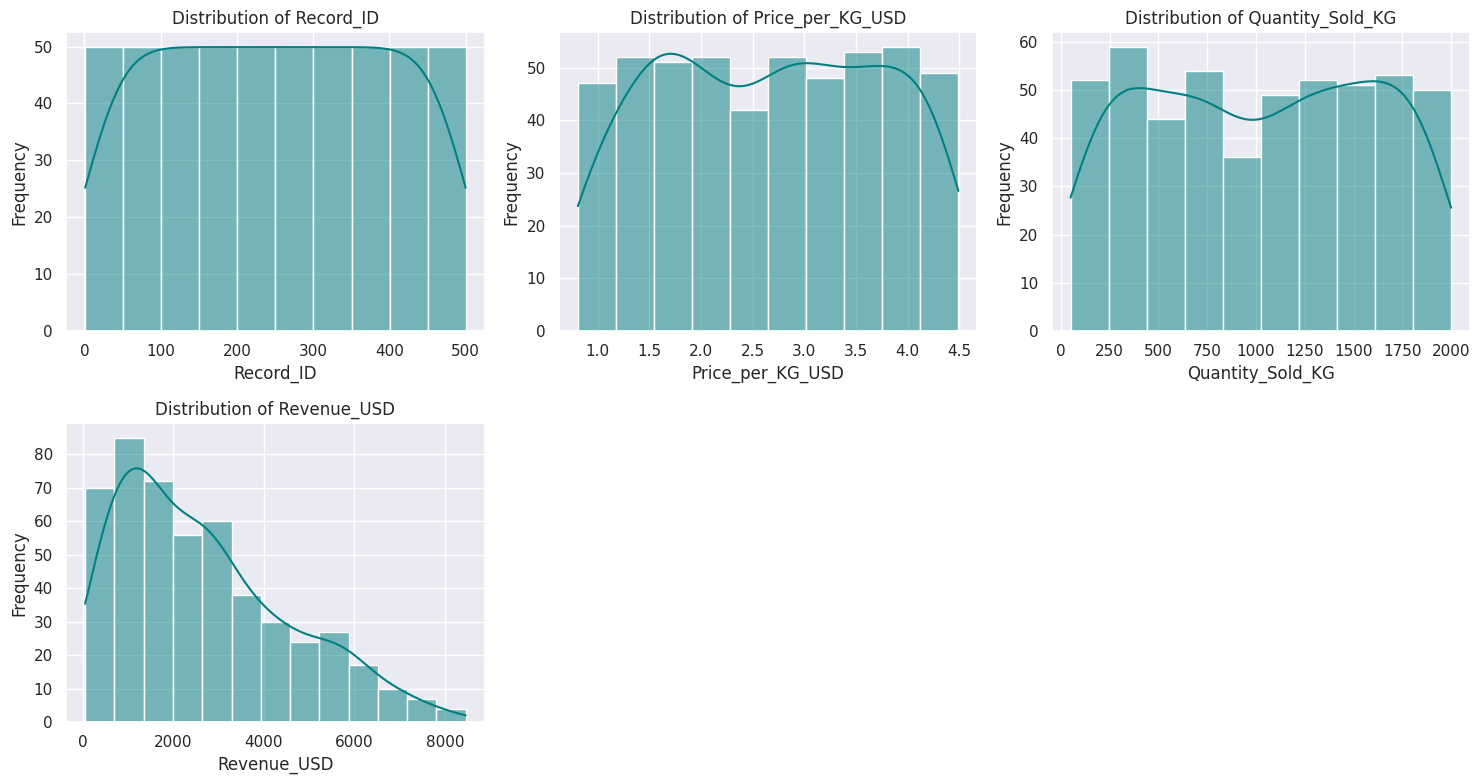

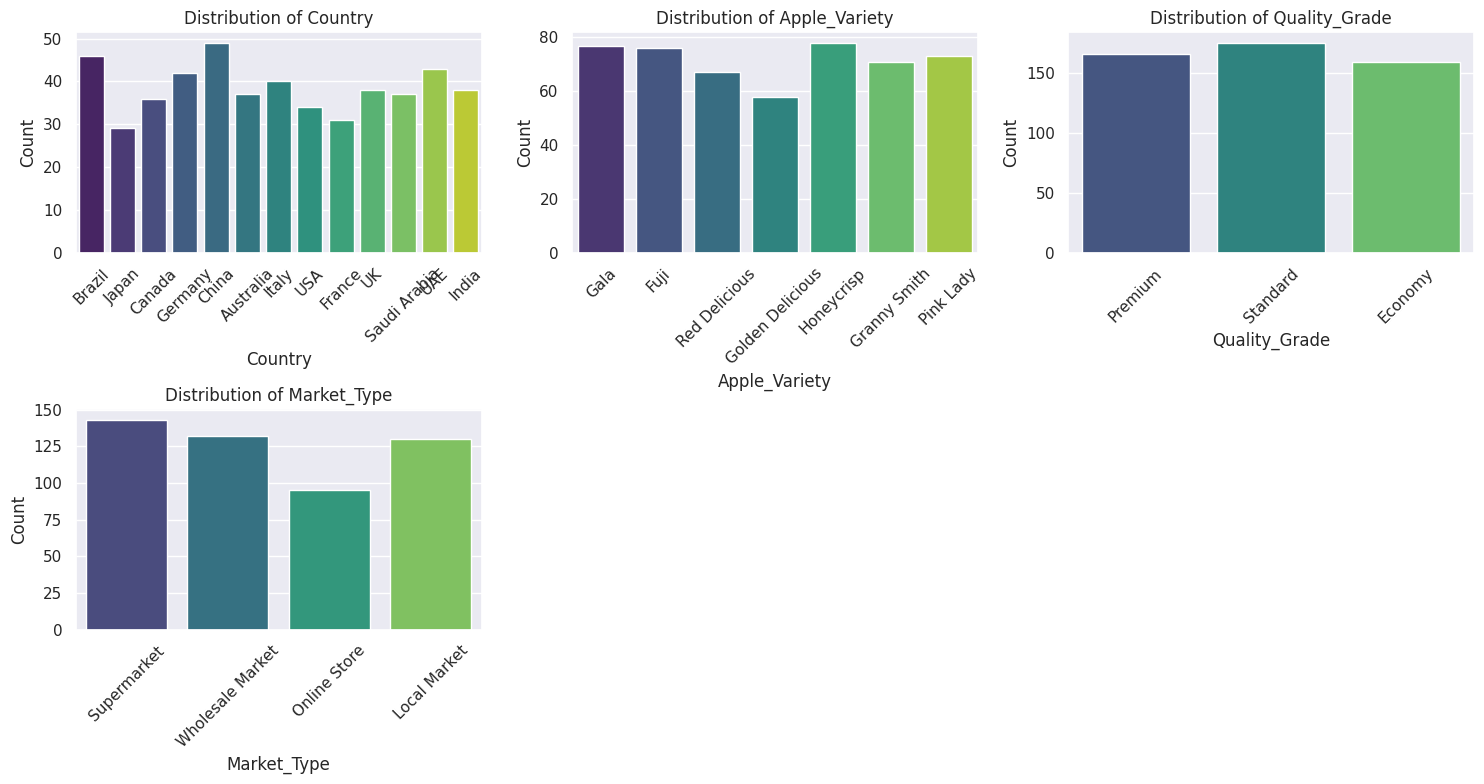

--- Categorical Value Counts ---

Value counts for Country:
Country
China           49
Brazil          46
UAE             43
Germany         42
Italy           40
UK              38
India           38
Australia       37
Saudi Arabia    37
Canada          36
USA             34
France          31
Japan           29
Name: count, dtype: int64

Value counts for Apple_Variety:
Apple_Variety
Honeycrisp          78
Gala                77
Fuji                76
Pink Lady           73
Granny Smith        71
Red Delicious       67
Golden Delicious    58
Name: count, dtype: int64

Value counts for Quality_Grade:
Quality_Grade
Standard    175
Premium     166
Economy     159
Name: count, dtype: int64

Value counts for Market_Type:
Market_Type
Supermarket         143
Wholesale Market    132
Local Market        130
Online Store         95
Name: count, dtype: int64


In [11]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

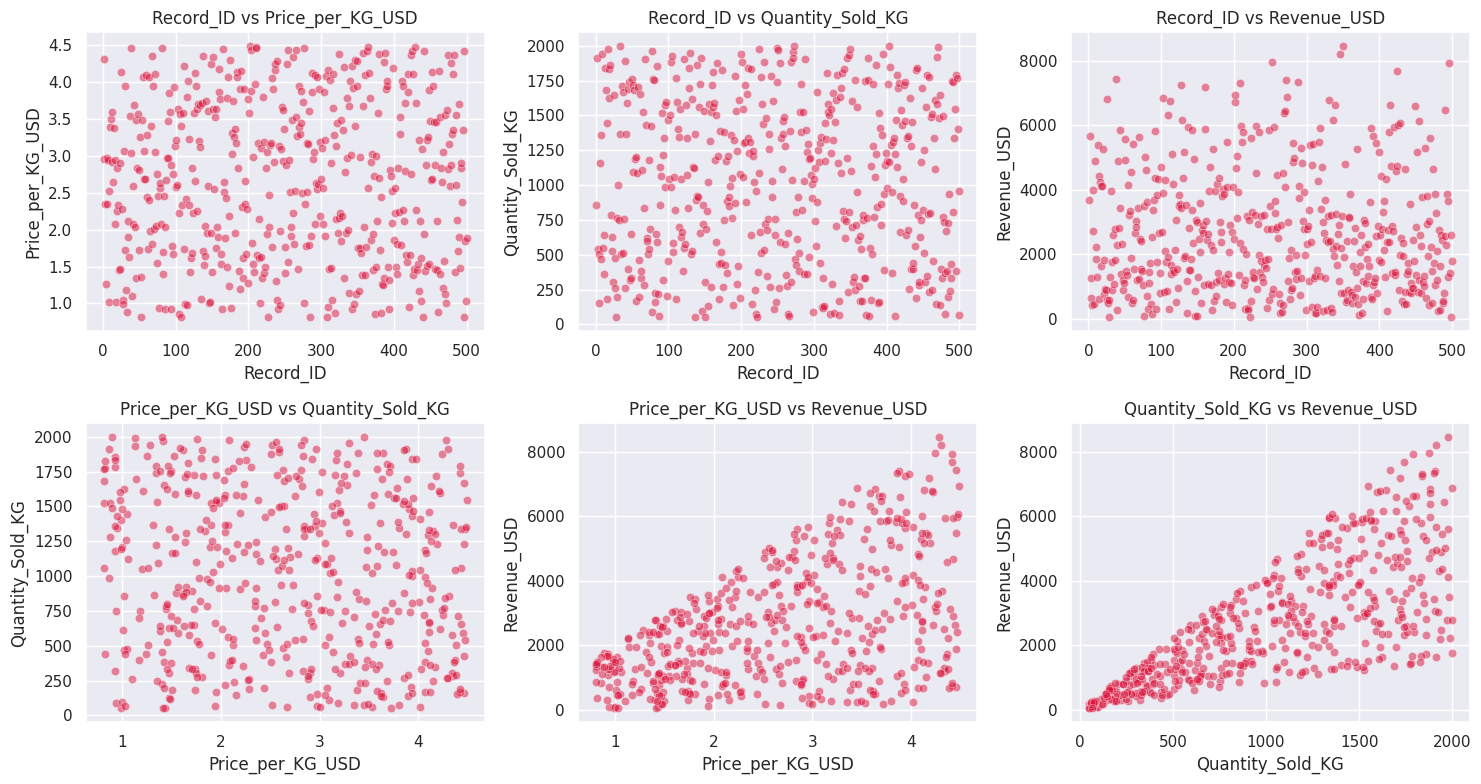

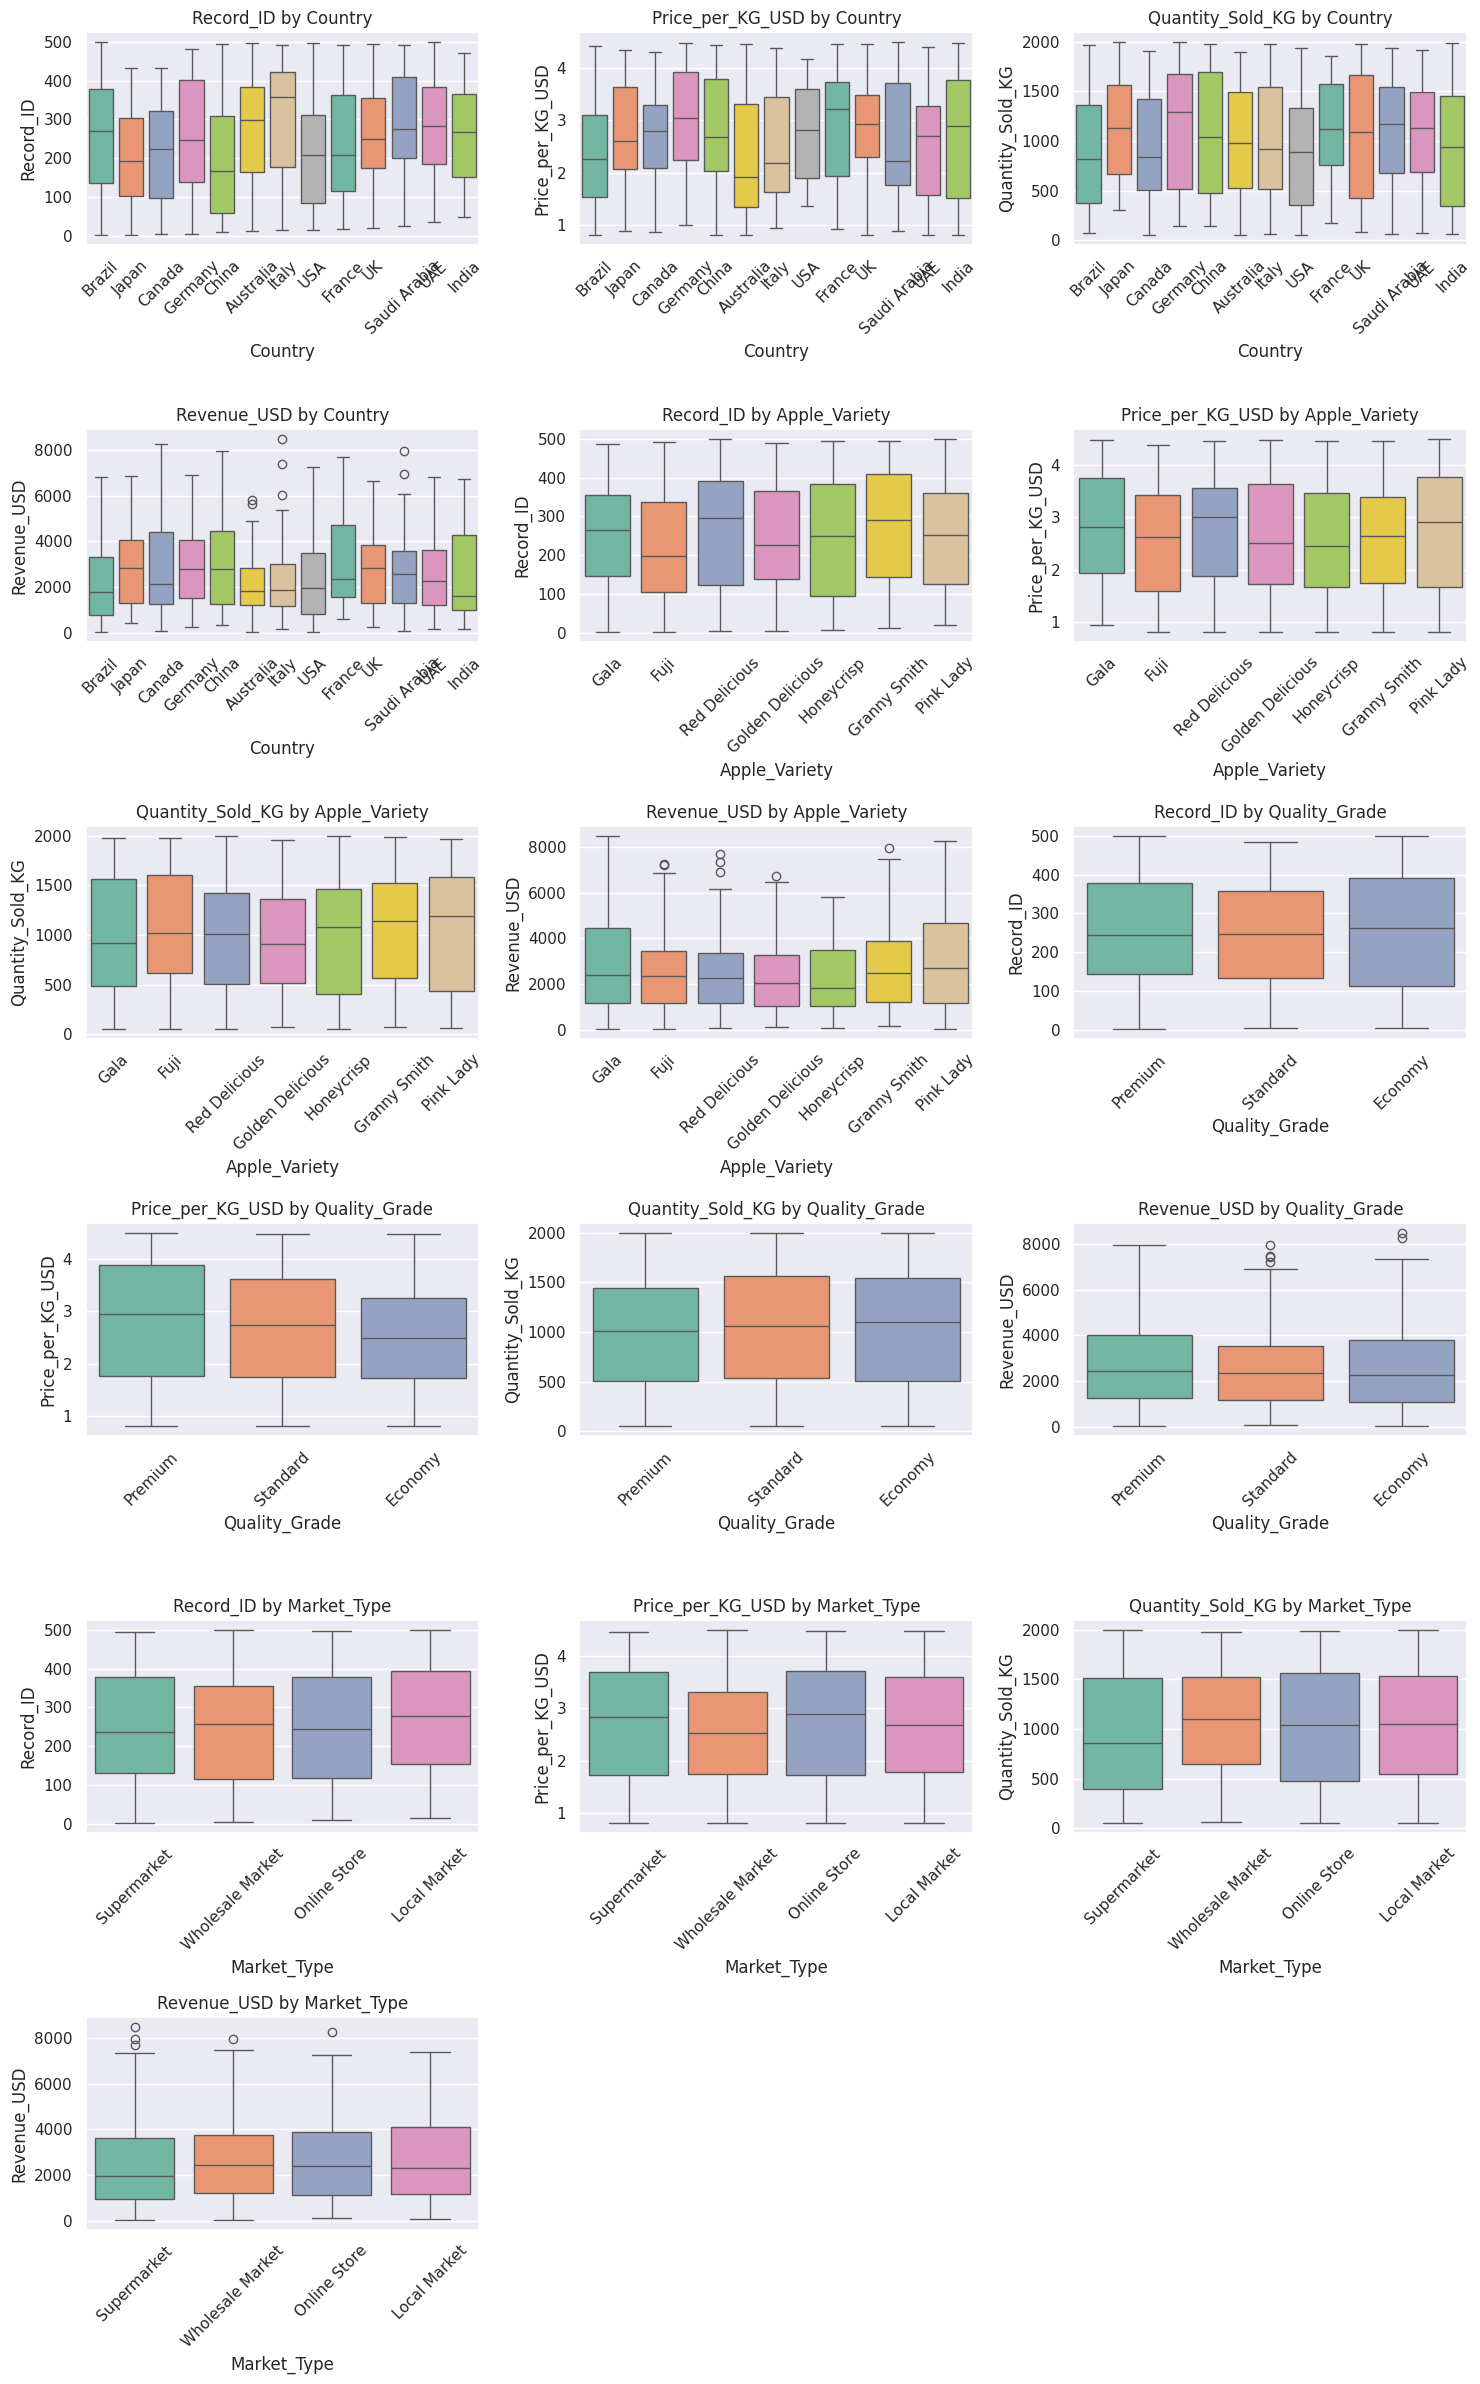

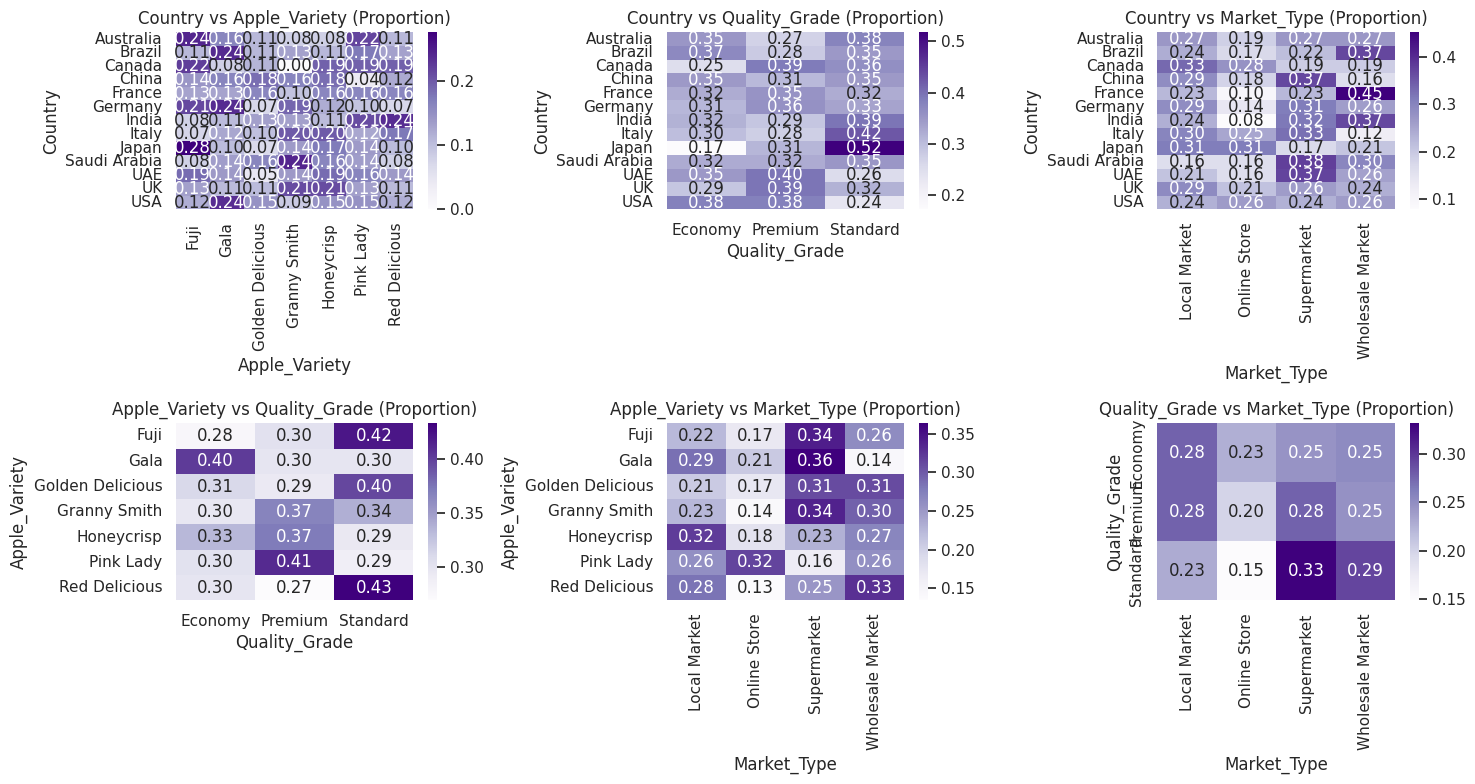

In [12]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: Apple_Variety...


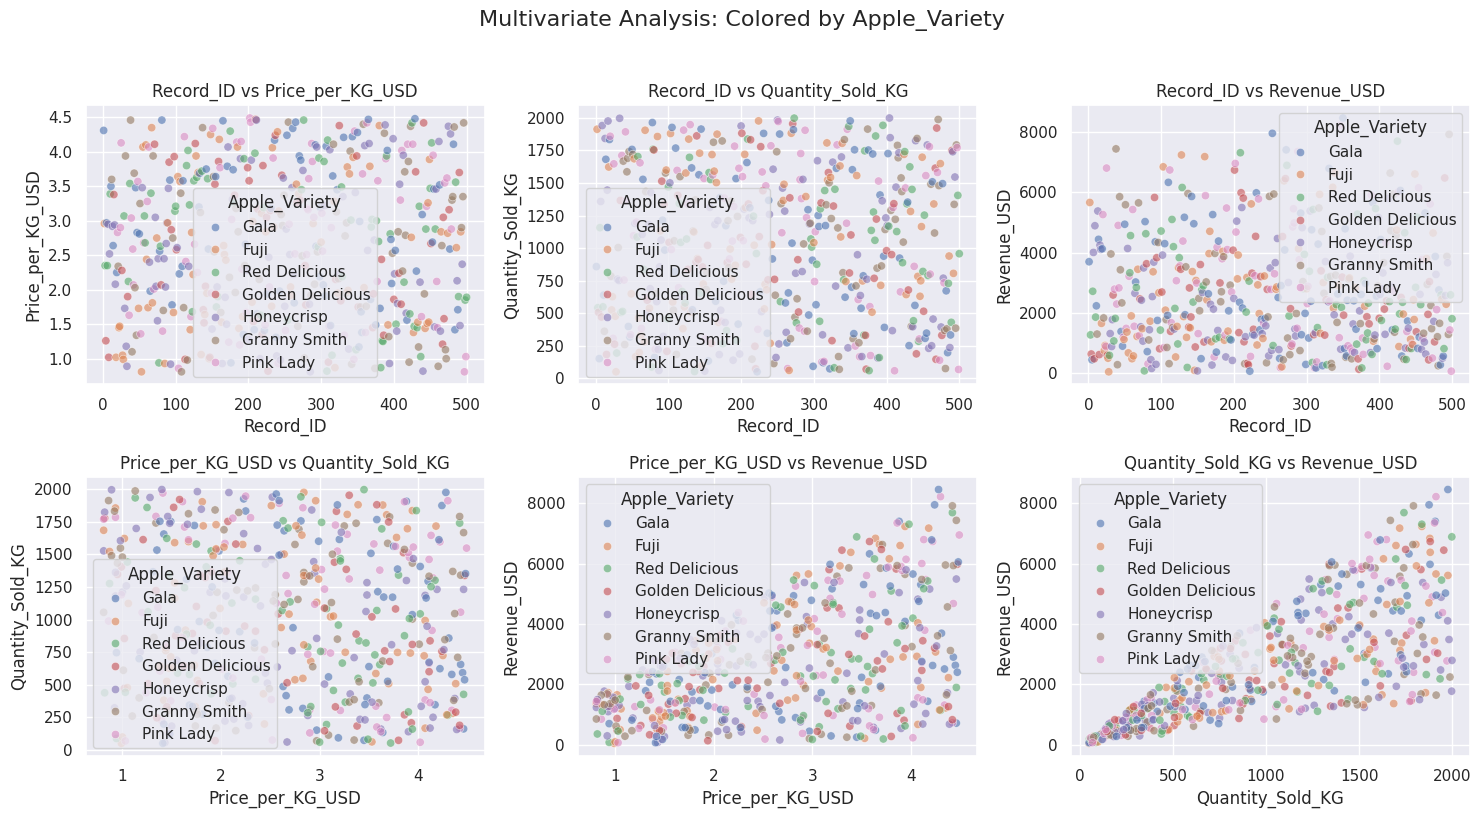


Analyzing relationships with Hue: Quality_Grade...


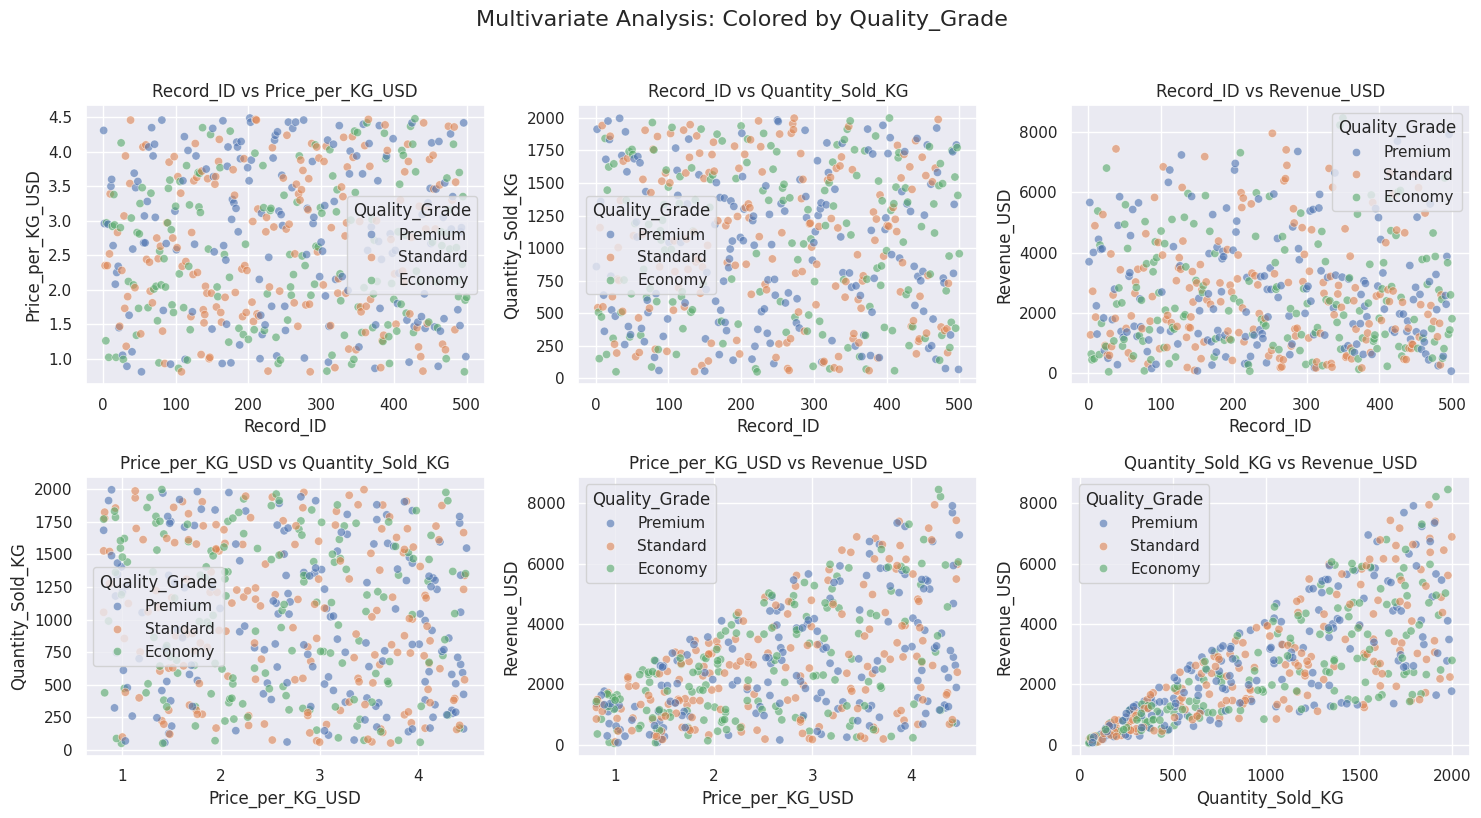


Analyzing relationships with Hue: Market_Type...


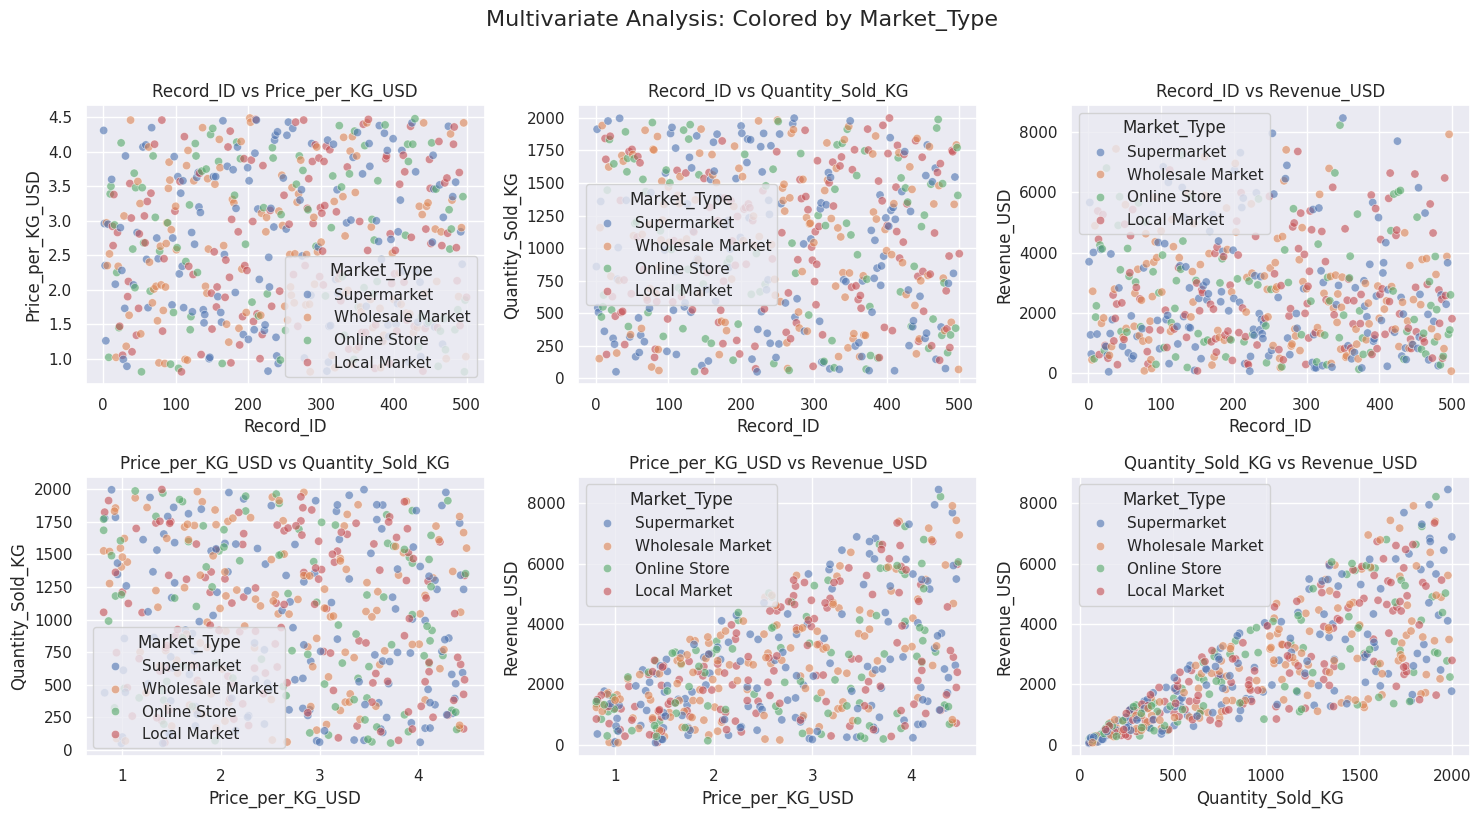

In [15]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

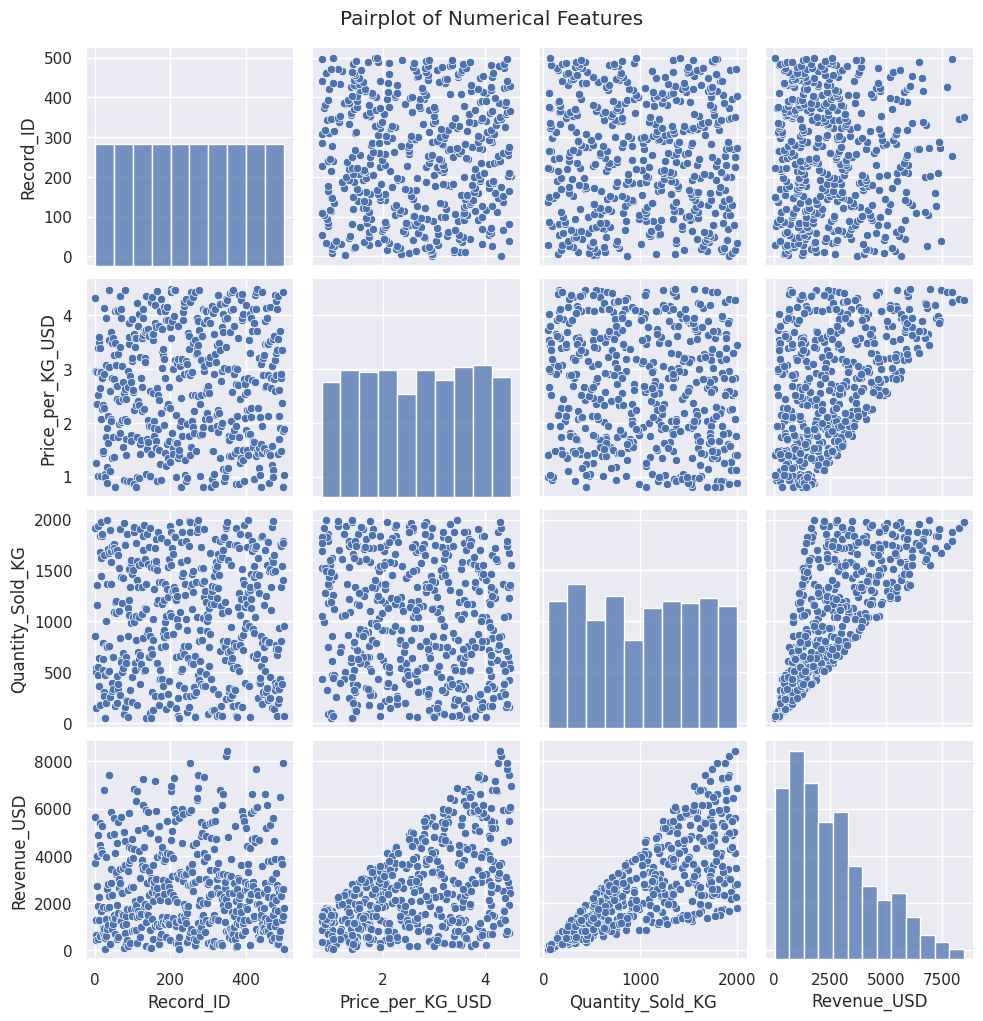

In [13]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

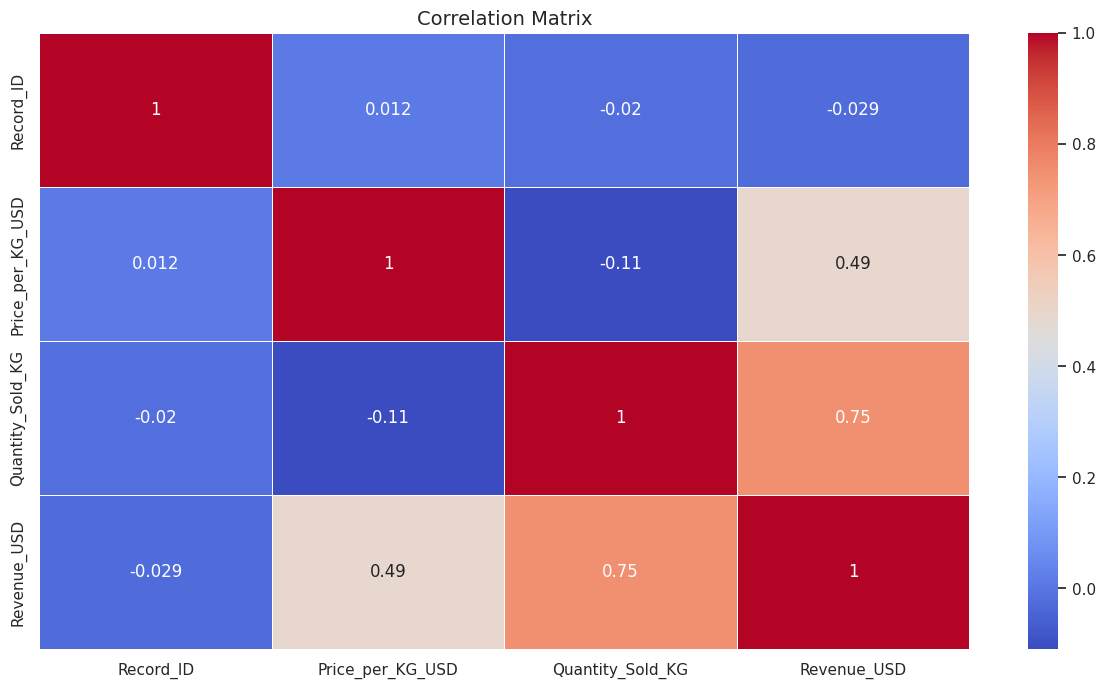

In [14]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. ENGINEERING ELASTICITY METRICS (LOG TRANSFORMS) ---
 Engineered: Log-transformed Price and Quantity for econometric modeling.

--- 2. PRICE ELASTICITY OF DEMAND (OLS REGRESSION) ---
 Regression P-Value (Price Impact): 5.4460e-02
 Insight: Null Hypothesis accepted. Price changes do not mathematically alter consumer demand volume.


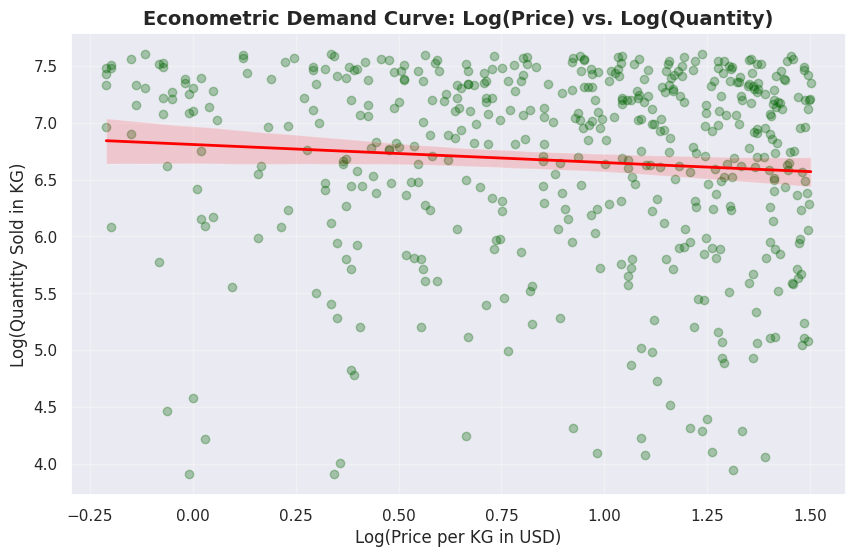


--- 3. THE PREMIUM QUALITY MARKUP (ONE-WAY ANOVA) ---
ANOVA P-Value (Quality Grading): 1.9487e-02
 Insight: The variance between quality grades is statistically significant.
   -> Grading standardization effectively creates rigid, mathematical price floors in the market.


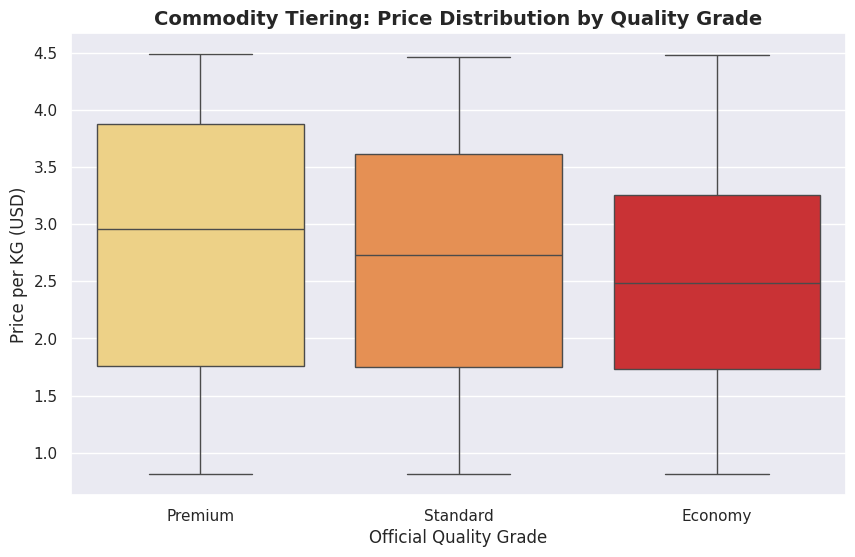


--- 4. MARKET TYPE ARBITRAGE (INDEPENDENT T-TEST) ---


In [16]:
import scipy.stats as stats
import statsmodels.api as sm

print("--- 1. ENGINEERING ELASTICITY METRICS (LOG TRANSFORMS) ---")
# To calculate the Price Elasticity of Demand, economists use a Log-Log model.
# We have to apply a natural logarithm to both Price and Quantity.

df['Log_Price'] = np.log(df['Price_per_KG_USD'])
df['Log_Quantity'] = np.log(df['Quantity_Sold_KG'])

print(" Engineered: Log-transformed Price and Quantity for econometric modeling.")

# ::::::: ECONOMETRIC HYPOTHESIS TESTING :::::::

print("\n--- 2. PRICE ELASTICITY OF DEMAND (OLS REGRESSION) ---")
# Demand is strictly elastic. As price increases, quantity sold strictly decreases.
# By regressing Log_Quantity on Log_Price, the resulting coefficient is our exact Elasticity metric.

elasticity_data = df[['Log_Price', 'Log_Quantity']].dropna()

# Defining Dependent (Y) and Independent (X) variables
Y_elast = elasticity_data['Log_Quantity']
X_elast = sm.add_constant(elasticity_data['Log_Price'])

# Fittng the Ordinary Least Squares (OLS) Regression
elast_model = sm.OLS(Y_elast, X_elast).fit()

print(f" Regression P-Value (Price Impact): {elast_model.pvalues['Log_Price']:.4e}")
if elast_model.pvalues['Log_Price'] < 0.05:
    elasticity_coefficient = elast_model.params['Log_Price']
    print(" Insight: Statistically significant demand curve detected.")
    print(f"   -> Price Elasticity Coefficient: {elasticity_coefficient:.2f}")

    if elasticity_coefficient < -1:
        print("   -> Market Diagnosis: HIGHLY ELASTIC. A 1% increase in price causes a >1% drop in sales. Do not raise prices!")
    elif elasticity_coefficient < 0:
        print("   -> Market Diagnosis: INELASTIC. A 1% increase in price causes a <1% drop in sales. You can safely raise prices.")
else:
    print(" Insight: Null Hypothesis accepted. Price changes do not mathematically alter consumer demand volume.")

# Visualizing the Demand Curve
plt.figure(figsize=(10, 6))
sns.regplot(x='Log_Price', y='Log_Quantity', data=elasticity_data, scatter_kws={'alpha':0.3, 'color':'darkgreen'}, line_kws={'color':'red', 'linewidth':2})
plt.title('Econometric Demand Curve: Log(Price) vs. Log(Quantity)', fontsize=14, fontweight='bold')
plt.xlabel('Log(Price per KG in USD)')
plt.ylabel('Log(Quantity Sold in KG)')
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 3. THE PREMIUM QUALITY MARKUP (ONE-WAY ANOVA) ---")
# 'Quality_Grade' --> fundamentally dictates distinct pricing tiers in the market.

if 'Quality_Grade' in df.columns:
    grades = df['Quality_Grade'].dropna().unique()
    grade_groups = [df[df['Quality_Grade'] == grade]['Price_per_KG_USD'].dropna() for grade in grades]

    f_stat, p_val_anova = stats.f_oneway(*grade_groups)

    print(f"ANOVA P-Value (Quality Grading): {p_val_anova:.4e}")
    if p_val_anova < 0.05:
        print(" Insight: The variance between quality grades is statistically significant.")
        print("   -> Grading standardization effectively creates rigid, mathematical price floors in the market.")
    else:
        print(" Insight: The market does not mathematically reward higher quality grades with distinct pricing.")

    # Visualize the Pricing Distribution across Grades
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Quality_Grade', y='Price_per_KG_USD', data=df, palette='YlOrRd')
    plt.title('Commodity Tiering: Price Distribution by Quality Grade', fontsize=14, fontweight='bold')
    plt.xlabel('Official Quality Grade')
    plt.ylabel('Price per KG (USD)')
    plt.show()


print("\n--- 4. MARKET TYPE ARBITRAGE (INDEPENDENT T-TEST) ---")
# Wholesale markets have mathematically different pricing variance than Retail markets.
# Assuming that 'Market_Type' contains 'Wholesale' and 'Retail' tags.

if 'Market_Type' in df.columns:
    # Safely extracting wholesale and retail strings, ignoring case
    wholesale_prices = df[df['Market_Type'].str.contains('Wholesale', case=False, na=False)]['Price_per_KG_USD'].dropna()
    retail_prices = df[df['Market_Type'].str.contains('Retail', case=False, na=False)]['Price_per_KG_USD'].dropna()

    if len(wholesale_prices) > 0 and len(retail_prices) > 0:
        t_stat_market, p_val_market = stats.ttest_ind(wholesale_prices, retail_prices, equal_var=False)

        print(f"Welch's T-Test P-Value (Market Arbitrage): {p_val_market:.4e}")
        if p_val_market < 0.05:
            print(" Insight: Statistically significant arbitrage detected between Wholesale and Retail pipelines.")
            markup = ((retail_prices.mean() - wholesale_prices.mean()) / wholesale_prices.mean()) * 100
            print(f"   -> Average Retail Markup: {markup:.2f}%")
        else:
            print(" Insight: Wholesale and Retail pipelines share identical mathematical pricing variances.")

## Macro-Economics & Post-Hoc Diaganosis

--- 1. GLOBAL PURCHASING POWER (KRUSKAL-WALLIS H-TEST) ---
Kruskal-Wallis P-Value (Geographic Variance): 2.0028e-01
 Insight: The commodity has achieved Global Price Parity. Location does not dictate price.


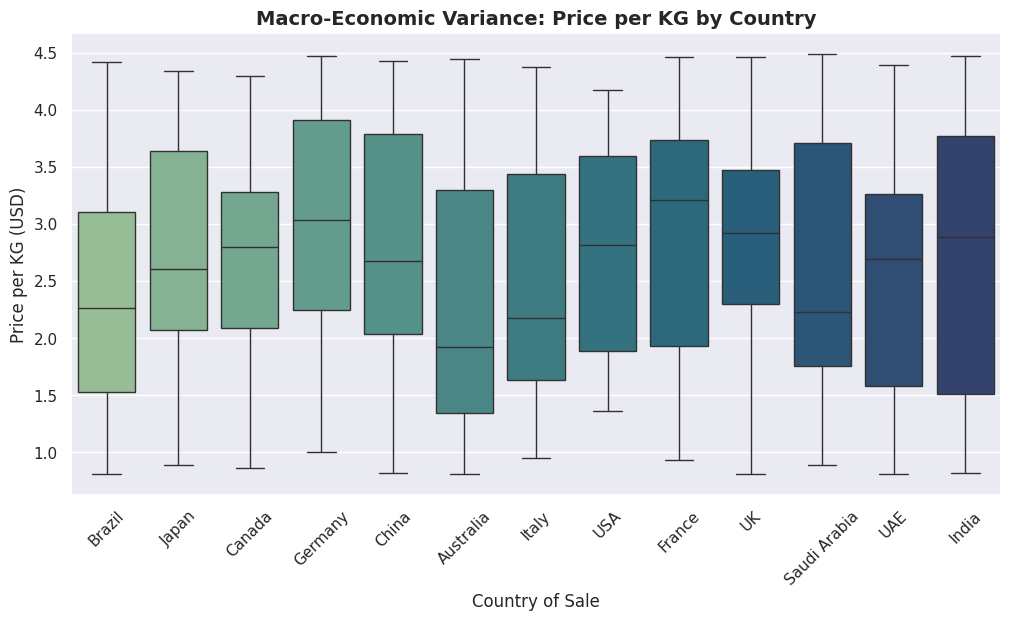


--- 2. THE CULTIVAR PREMIUM (TUKEY'S HSD TEST) ---
 Insight: All apple varieties are priced identically. Genetics do not yield a premium.

--- 3. REVENUE CONCENTRATION (THE GINI COEFFICIENT) ---
Gini Coefficient for Revenue: 0.3945
 Insight: High Equality. Revenue is generated smoothly and evenly across all transactions.


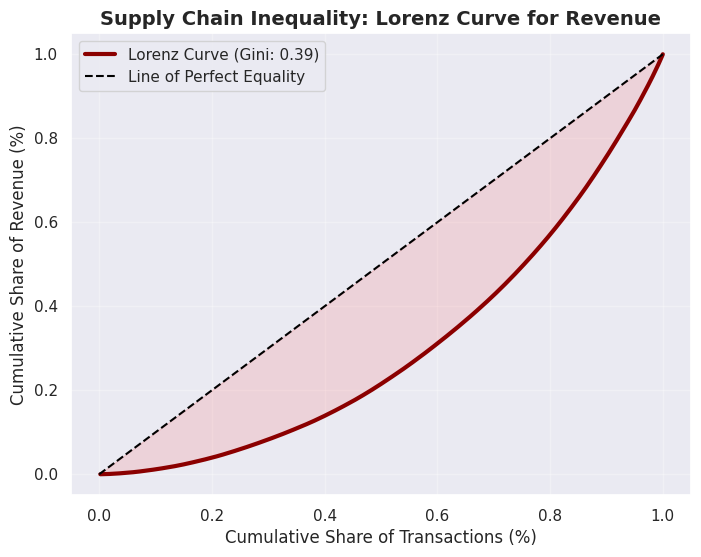

In [17]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("--- 1. GLOBAL PURCHASING POWER (KRUSKAL-WALLIS H-TEST) ---")
# Because of differing global economies, the median price of an apple
# varies fundamentally by Country.
# We use Kruskal-Wallis because international prices contain extreme currency outliers,
# making standard parametric ANOVA invalid.

if 'Country' in df.columns:
    countries = df['Country'].dropna().unique()
    country_groups = [df[df['Country'] == c]['Price_per_KG_USD'].dropna() for c in countries]

    # Kruskal-Wallis Non-Parametric Test
    h_stat, p_val_kw = stats.kruskal(*country_groups)

    print(f"Kruskal-Wallis P-Value (Geographic Variance): {p_val_kw:.4e}")
    if p_val_kw < 0.05:
        print(" Insight: Statistically significant geographic price divergence detected.")
        print("   -> The asset is NOT globally homogenized. Arbitrage opportunities exist between countries.")
    else:
        print(" Insight: The commodity has achieved Global Price Parity. Location does not dictate price.")

    # Visualize Geographic Variance
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Country', y='Price_per_KG_USD', data=df, palette='crest')
    plt.title('Macro-Economic Variance: Price per KG by Country', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.xlabel('Country of Sale')
    plt.ylabel('Price per KG (USD)')
    plt.show()


print("\n--- 2. THE CULTIVAR PREMIUM (TUKEY'S HSD TEST) ---")
# If Certain apple genetics (Varieties) command a strict premium over others.
# If an ANOVA proves variance exists, Tukey's HSD tells us EXACTLY which varieties beat the others.

if 'Apple_Variety' in df.columns:
    # quickly confirming overall variance with ANOVA
    varieties = df['Apple_Variety'].dropna().unique()
    variety_groups = [df[df['Apple_Variety'] == v]['Price_per_KG_USD'].dropna() for v in varieties]
    f_stat_var, p_val_var = stats.f_oneway(*variety_groups)

    if p_val_var < 0.05:
        print(" ANOVA Confirmed: Apple varieties have different pricing distributions. Running Post-Hoc Analysis...")

        # Running Tukey's HSD to find the pairwise differences
        tukey_data = df[['Apple_Variety', 'Price_per_KG_USD']].dropna()
        tukey_results = pairwise_tukeyhsd(endog=tukey_data['Price_per_KG_USD'],
                                          groups=tukey_data['Apple_Variety'],
                                          alpha=0.05)

        # Display the summary table of which varieties mathematically beat others
        print("\n TUKEY HSD POST-HOC RESULTS (STATISTICALLY SIGNIFICANT MATCHUPS ONLY):")
        tukey_df = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])
        significant_matchups = tukey_df[tukey_df['reject'] == True]
        print(significant_matchups[['group1', 'group2', 'meandiff', 'p-adj']].head(10)) # Showing top 10
        print("   -> Interpretation: 'meandiff' is the exact USD premium Group 2 holds over Group 1.")
    else:
        print(" Insight: All apple varieties are priced identically. Genetics do not yield a premium.")


print("\n--- 3. REVENUE CONCENTRATION (THE GINI COEFFICIENT) ---")
# Does a small percentage of sales volume generate the vast majority of the revenue?
# Here we are calculating the Gini Coefficient (0 = perfect equality, 1 = total monopoly/inequality).

def calculate_gini(array):
    # Calculating the Gini coefficient of a numpy array.
    array = array.flatten()
    if np.amin(array) < 0:
        array -= np.amin(array) # Values cannot be negative <---
    array += 0.0000001 # Values cannot be 0  <---
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return ((np.sum((2 * index - n  - 1) * array)) / (n * np.sum(array)))

gini_index = calculate_gini(df['Revenue_USD'].dropna().values)

print(f"Gini Coefficient for Revenue: {gini_index:.4f}")
if gini_index > 0.6:
    print(" Insight: Extreme Revenue Inequality (Pareto Principle Active).")
    print("   -> A massive portion of your total supply chain revenue is locked inside a tiny fraction of outlier transactions.")
elif gini_index > 0.4:
    print(" Insight: Moderate Revenue Inequality. Typical for corporate supply chains.")
else:
    print(" Insight: High Equality. Revenue is generated smoothly and evenly across all transactions.")

# Visualizing the Lorenz Curve (The visual representation of the Gini Coefficient)
revenue_sorted = np.sort(df['Revenue_USD'].dropna().values)
cumulative_revenue = np.cumsum(revenue_sorted) / np.sum(revenue_sorted)
cumulative_population = np.arange(1, len(revenue_sorted) + 1) / len(revenue_sorted)

plt.figure(figsize=(8, 6))
plt.plot(cumulative_population, cumulative_revenue, color='darkred', linewidth=3, label=f'Lorenz Curve (Gini: {gini_index:.2f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Line of Perfect Equality')
plt.title('Supply Chain Inequality: Lorenz Curve for Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative Share of Transactions (%)')
plt.ylabel('Cumulative Share of Revenue (%)')
plt.fill_between(cumulative_population, cumulative_population, cumulative_revenue, color='red', alpha=0.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature Engineering

In [21]:
from sklearn.preprocessing import StandardScaler

print("--- 1. TARGET ISOLATION (CONTINUOUS REGRESSION) ---")
# We are building a Regression algorithm to predict the exact continuous price of the commodity.
# We must isolate the target variable (Y) from the independent features (X).

ml_df = df.drop(columns=['Record_ID', 'Date', 'Revenue_USD', 'Log_Price', 'Log_Quantity'], errors='ignore').dropna()

# Define the Target Variable (Y)
y = ml_df['Price_per_KG_USD']

print(" Target Formulated: 'Price_per_KG_USD' isolated for Regression modeling.")
print(" Data Leakage Prevented: 'Revenue_USD' successfully purged from the feature space.")

print("\n--- 2. CATEGORICAL ENCODING (ONE-HOT VECTORIZATION) ---")
# Machine learning algorithms require strict numerical matrices.

categorical_features = ['Country', 'Apple_Variety', 'Quality_Grade', 'Market_Type']

# Execute One-Hot Vectorization
X_encoded = pd.get_dummies(ml_df.drop(columns=['Price_per_KG_USD']), columns=categorical_features, drop_first=True)

print(f" Categorical encoding applied. Feature matrix expanded to {X_encoded.shape[1]} dimensions.")


print("\n--- 3. CONTINUOUS FEATURE SCALING ---")

# Initialize the Standard Scaler
scaler = StandardScaler()

# We only scale the continuous features, leaving the binary dummy variables intact
continuous_features = ['Quantity_Sold_KG']
X_encoded[continuous_features] = scaler.fit_transform(X_encoded[continuous_features])

# The final Feature Matrix (X)
X = X_encoded.copy()

print(" Continuous variance standardized (Mean=0, Variance=1).")
print("\n Final Machine-Readable Feature Matrix (X) Preview:")
print(X.head())

--- 1. TARGET ISOLATION (CONTINUOUS REGRESSION) ---
 Target Formulated: 'Price_per_KG_USD' isolated for Regression modeling.
 Data Leakage Prevented: 'Revenue_USD' successfully purged from the feature space.

--- 2. CATEGORICAL ENCODING (ONE-HOT VECTORIZATION) ---
 Categorical encoding applied. Feature matrix expanded to 24 dimensions.

--- 3. CONTINUOUS FEATURE SCALING ---
 Continuous variance standardized (Mean=0, Variance=1).

 Final Machine-Readable Feature Matrix (X) Preview:
   Quantity_Sold_KG  Country_Brazil  Country_Canada  Country_China  \
0         -0.281073            True           False          False   
1          1.544213           False           False          False   
2         -0.827794           False            True          False   
3         -0.888349            True           False          False   
4         -1.504275           False           False          False   

   Country_France  Country_Germany  Country_India  Country_Italy  \
0           False        

# Advances Feature Engineering

--- 1. SMOOTHED TARGET ENCODING (HIGH-CARDINALITY) ---
 Engineered: Bayesian Smoothed Target Encoding applied to Geography and Genetics.

--- 2. META-FEATURE ENGINEERING (CLUSTERING AS A FEATURE) ---
 Engineered: Unsupervised Meta-Clustering injected into the Supervised feature space.

--- 3. NON-LINEAR QUANTILE DISCRETIZATION ---
 Engineered: Continuous supply volume transformed into discrete Quantile Deciles.

--- 4. FINAL ADVANCED FEATURE MATRIX ASSEMBLY ---
 Advanced Feature Matrix Assembled: 8 highly-dense, mathematically rich dimensions.

 Advanced Feature Matrix (X_adv) Preview:
   Quantity_Sold_KG  Quantity_Decile_Bin  Country_Target_Encoded  \
0               858                  4.0                2.467400   
1              1913                  9.0                2.652933   
2               542                  2.0                2.722487   
3               507                  2.0                2.467400   
4               151                  0.0                2.903931   

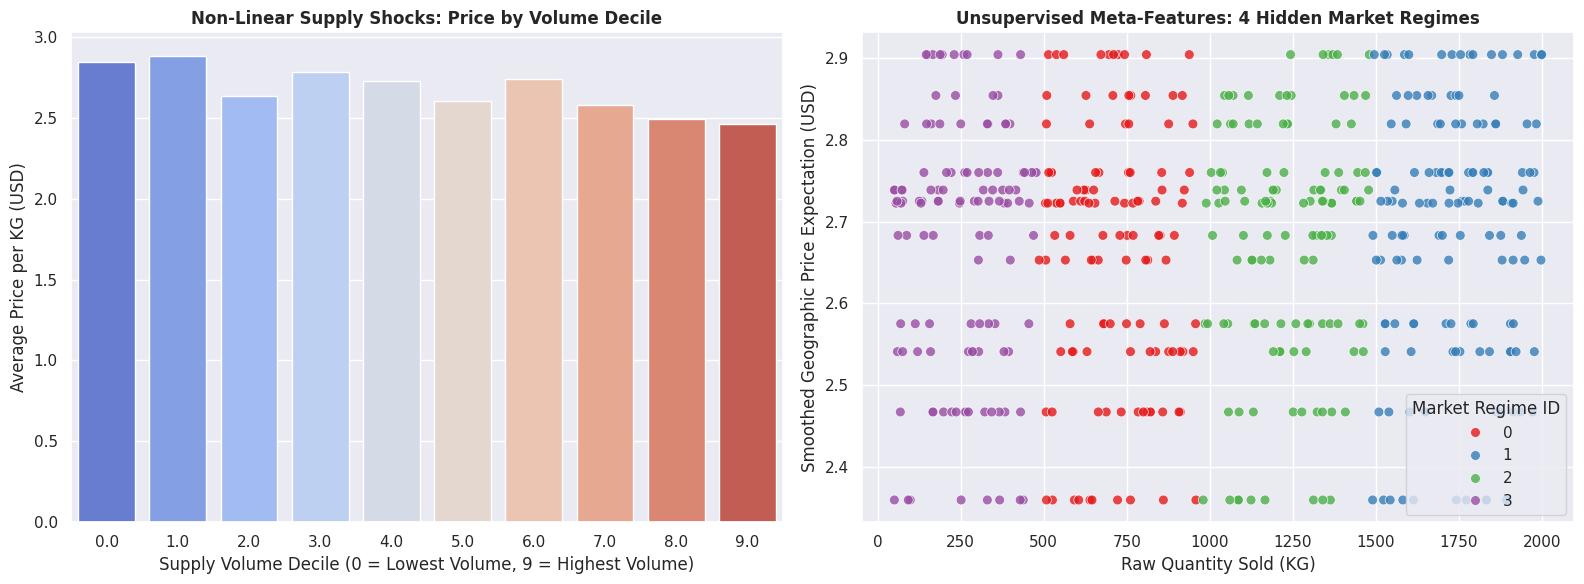

In [26]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import KBinsDiscretizer

print("--- 1. SMOOTHED TARGET ENCODING (HIGH-CARDINALITY) ---")
# One-Hot Encoding explodes the matrix. Target Encoding replaces a category (like 'Fuji')
# with the mean of the Target ('Price_per_KG_USD') for that specific category.

smoothing_weight = 10
global_mean_price = ml_df['Price_per_KG_USD'].mean()

def smoothed_target_encode(df, category_col, target_col, weight, global_mean):
    # Calculating the count and mean of the target for each category
    agg = df.groupby(category_col)[target_col].agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']

    # Applyying the Bayesian smoothing formula
    smoothed_means = (counts * means + weight * global_mean) / (counts + weight)
    return df[category_col].map(smoothed_means)

# Applyying to Country and Apple_Variety
ml_df['Country_Target_Encoded'] = smoothed_target_encode(ml_df, 'Country', 'Price_per_KG_USD', smoothing_weight, global_mean_price)
ml_df['Variety_Target_Encoded'] = smoothed_target_encode(ml_df, 'Apple_Variety', 'Price_per_KG_USD', smoothing_weight, global_mean_price)

print(" Engineered: Bayesian Smoothed Target Encoding applied to Geography and Genetics.")


print("\n--- 2. META-FEATURE ENGINEERING (CLUSTERING AS A FEATURE) ---")

# Isolate the numeric features for clustering
cluster_features = ['Quantity_Sold_KG', 'Country_Target_Encoded', 'Variety_Target_Encoded']
X_cluster = ml_df[cluster_features].fillna(0)

# Deploy K-Means to find 4 hidden supply chain regimes
kmeans_meta = KMeans(n_clusters=4, random_state=42, n_init=10)
ml_df['Hidden_Market_Regime'] = kmeans_meta.fit_predict(X_cluster)

# One-Hot Encode the resulting Regime ID so the Regressor can use it
regime_dummies = pd.get_dummies(ml_df['Hidden_Market_Regime'], prefix='Regime', drop_first=True)
# Do not concat regime_dummies to ml_df yet, we will add it directly to X_adv

print(" Engineered: Unsupervised Meta-Clustering injected into the Supervised feature space.")


print("\n--- 3. NON-LINEAR QUANTILE DISCRETIZATION ---")
# Using KBinsDiscretizer to mathematically bin the supply volume into deciles (10 equal-sized buckets).

discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
ml_df['Quantity_Decile_Bin'] = discretizer.fit_transform(ml_df[['Quantity_Sold_KG']])

print(" Engineered: Continuous supply volume transformed into discrete Quantile Deciles.")


print("\n--- 4. FINAL ADVANCED FEATURE MATRIX ASSEMBLY ---")
# Assembling the final, highly advanced matrix
# Weare mapping the ordinal Quality Grade to strict integers (assuming grades like A, B, C or 1, 2, 3)
if ml_df['Quality_Grade'].dtype == 'O':
    ml_df['Quality_Grade_Ordinal'] = pd.factorize(ml_df['Quality_Grade'])[0]
else:
    ml_df['Quality_Grade_Ordinal'] = ml_df['Quality_Grade']

# Defining the base features from ml_df
base_features = [
    'Quantity_Sold_KG', 'Quantity_Decile_Bin',
    'Country_Target_Encoded', 'Variety_Target_Encoded',
    'Quality_Grade_Ordinal'
]

# Final Independent Variables (X) and Dependent Variable (Y)
X_adv = ml_df[base_features].copy()

# Concatenate the one-hot encoded regime dummies, ensuring they are integers
X_adv = pd.concat([X_adv, regime_dummies.astype(int)], axis=1)

y_adv = ml_df['Price_per_KG_USD'].copy()

print(f" Advanced Feature Matrix Assembled: {X_adv.shape[1]} highly-dense, mathematically rich dimensions.")
print("\n Advanced Feature Matrix (X_adv) Preview:")
print(X_adv.head())

print("--- VISUALIZING THE ENGINEERED MATRIX ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Visualizing the Quantile Discretization (Volume Deciles vs Price)
# Does slicing the volume into 10 buckets reveal a non-linear pricing trend?
sns.barplot(x='Quantity_Decile_Bin', y='Price_per_KG_USD', data=ml_df, ax=axes[0], palette='coolwarm', errorbar=None)
axes[0].set_title('Non-Linear Supply Shocks: Price by Volume Decile', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Supply Volume Decile (0 = Lowest Volume, 9 = Highest Volume)')
axes[0].set_ylabel('Average Price per KG (USD)')

# 2. Visualizing the Hidden Market Regimes (Meta-Clustering)
# Plotting the Smoothed Target Encoded Country against Volume, colored by our Unsupervised Clusters
sns.scatterplot(x='Quantity_Sold_KG', y='Country_Target_Encoded', hue='Hidden_Market_Regime',
                data=ml_df, palette='Set1', alpha=0.8, ax=axes[1], s=50)
axes[1].set_title('Unsupervised Meta-Features: 4 Hidden Market Regimes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Raw Quantity Sold (KG)')
axes[1].set_ylabel('Smoothed Geographic Price Expectation (USD)')
axes[1].legend(title='Market Regime ID')

plt.tight_layout()
plt.show()

# Machine Learning

--- 1. OUT-OF-SAMPLE DATA SPLITTING ---
 Training Set: 400 commodity records
 Testing Set: 100 commodity records (Strictly Unseen)

--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---
 Both Tree-Based Regression Architectures successfully trained.

--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---
 Random Forest Performance:
 -> Mean Absolute Error (MAE): $0.91 per KG
 -> Root Mean Squared Error (RMSE): $1.07 per KG
 -> R-Squared (R2): -0.1647
----------------------------------------
 XGBoost Performance:
 -> Mean Absolute Error (MAE): $1.02 per KG
 -> Root Mean Squared Error (RMSE): $1.20 per KG
 -> R-Squared (R2): -0.4515

 The Random Forest mathematically outperformed the alternative.

--- 4. VISUALIZING PREDICTIVE ACCURACY ---


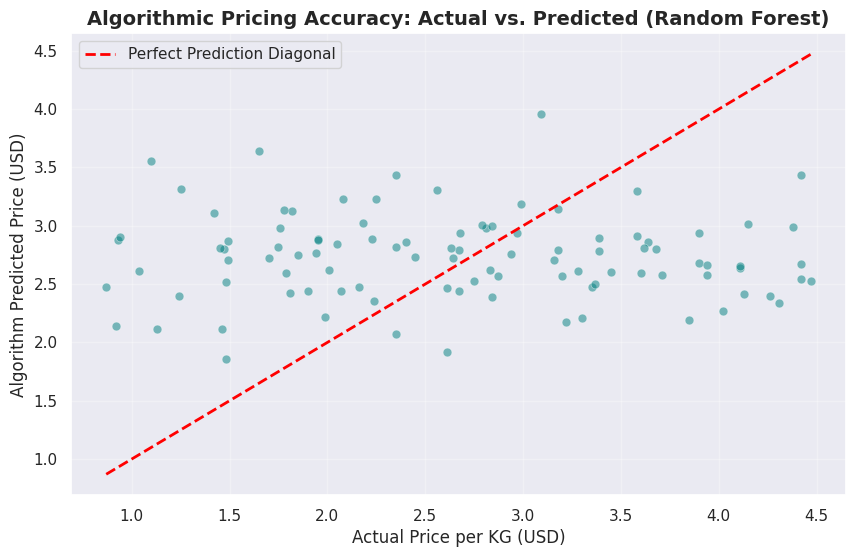


--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


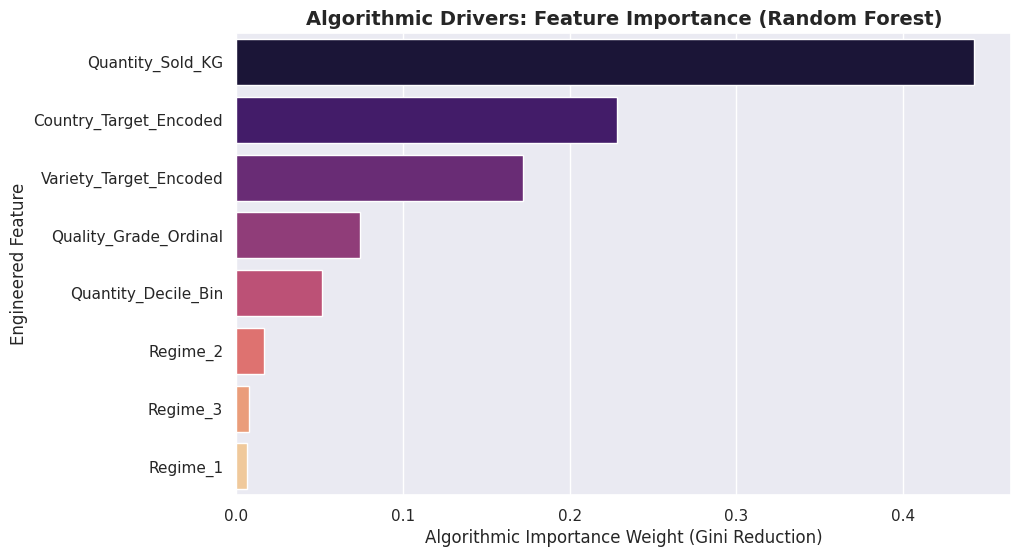

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("--- 1. OUT-OF-SAMPLE DATA SPLITTING ---")
# We split the data into 80% Training and 20% Out-of-Sample Testing.
# We hold out the test set to simulate predicting future, unseen market conditions.

# Ensuring all columns in X_adv are numerical (float) for robust compatibility with XGBoost
X_adv_numeric = X_adv.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X_adv_numeric, y_adv, test_size=0.2, random_state=42)

print(f" Training Set: {len(X_train)} commodity records")
print(f" Testing Set: {len(X_test)} commodity records (Strictly Unseen)")

print("\n--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---")

# 1. Random Forest (Bagging Architecture)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. XGBoost
# We use a lower learning rate (eta) to ensure the gradient descent converges smoothly
xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print(" Both Tree-Based Regression Architectures successfully trained.")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---")
# Force both models to predict the unseen 20% of the market.
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f" {name} Performance:")
    print(f" -> Mean Absolute Error (MAE): ${mae:.2f} per KG")
    print(f" -> Root Mean Squared Error (RMSE): ${rmse:.2f} per KG")
    print(f" -> R-Squared (R2): {r2:.4f}")
    return r2, mae

r2_rf, mae_rf = evaluate_model("Random Forest", y_test, rf_preds)
print("-" * 40)
r2_xgb, mae_xgb = evaluate_model("XGBoost", y_test, xgb_preds)

# Determine the superior architecture
best_model_name = "XGBoost" if r2_xgb > r2_rf else "Random Forest"
best_preds = xgb_preds if r2_xgb > r2_rf else rf_preds
best_model = xgb_model if r2_xgb > r2_rf else rf_model

print(f"\n The {best_model_name} mathematically outperformed the alternative.")


print("\n--- 4. VISUALIZING PREDICTIVE ACCURACY ---")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.5, color='teal', s=40)
# Plotting the Line of Perfect Prediction
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Diagonal')

plt.title(f'Algorithmic Pricing Accuracy: Actual vs. Predicted ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price per KG (USD)', fontsize=12)
plt.ylabel('Algorithm Predicted Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")

importances = pd.Series(best_model.feature_importances_, index=X_adv.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title(f'Algorithmic Drivers: Feature Importance ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.show()

# Thank You